In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt


d:\GP\Scimilarity_test\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Lung_combined.h5ad")
print(adata_1)


AnnData object with n_obs × n_vars = 65129 × 13117
    obs: 'cell_type', 'dataset', 'source'
    uns: 'cell_type_colors', 'dataset_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [3]:
adata_1.var.head()

""
LINC00115
FAM41C
SAMD11
NOC2L
KLHL17


In [4]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [5]:
adata_1.layers["counts"] = adata_1.X.copy()


In [6]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_1 = align_dataset(adata_1, ce.gene_order)
adata_1 = lognorm_counts(adata_1)

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi(adata, label_keys, embed_key,k_lisi=30):
    
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]  
    
    
    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        sil_scores[key] = silhouette_score(X, adata.obs[key].values)
  

    # Call compute_lisi
    lisi_scores = compute_lisi(X, metadata, label_colnames=label_keys)

    # Convert to DataFrame for easier handling
    lisi_df = pd.DataFrame(lisi_scores, columns=label_keys, index=adata.obs_names)
   
    # Combine results
    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.median().to_dict()
    }
    
    return scores

In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):
  
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values
        
        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [9]:

X = adata_1.X
embeddings= ce.get_embeddings(X)
adata_1.obsm["X_emb"] = embeddings

In [10]:
print(embeddings.shape)
# save combined embeddings to project directory
adata_1.write_h5ad(r"D:\GP\Notebooks\Scimilarity\Lung_embeddings.h5ad")


(65129, 128)


In [11]:
import scanpy as sc

In [12]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Lung_embeddings.h5ad")
print(adata_1)

AnnData object with n_obs × n_vars = 65129 × 28231
    obs: 'cell_type', 'dataset', 'source'
    uns: 'orig_genes'
    obsm: 'X_emb', 'X_pca', 'X_umap'
    layers: 'counts'


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [14]:
import matplotlib.pyplot as plt

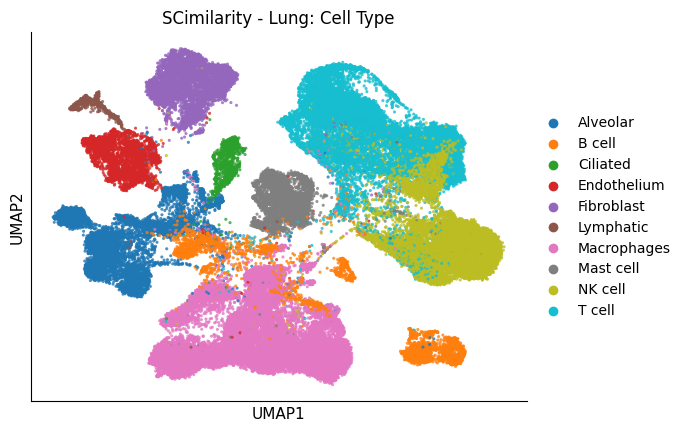

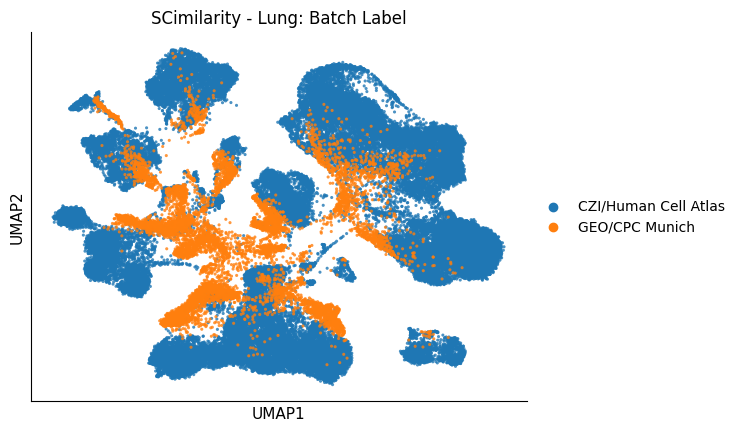

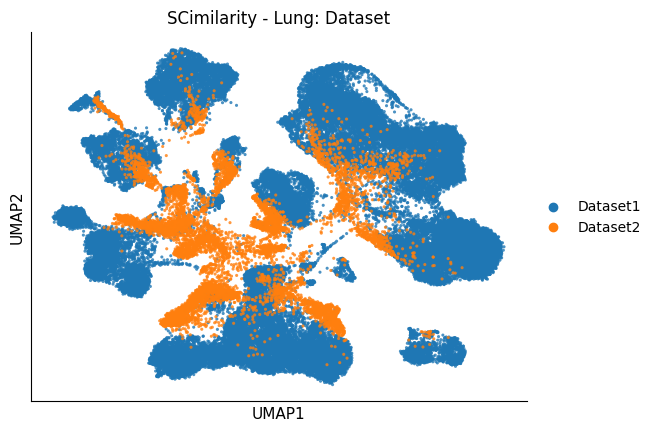

=== Logistic Regression ===
Accuracy: 0.7854363535297387
              precision    recall  f1-score   support

    Alveolar       0.67      0.95      0.79      1834
      B cell       0.64      0.05      0.09      1250
    Ciliated       1.00      0.88      0.94       433
 Endothelium       0.81      0.98      0.88       360
  Fibroblast       0.98      0.81      0.88       204
   Lymphatic       1.00      0.86      0.92       195
 Macrophages       0.84      0.94      0.89      2878
   Mast cell       0.85      0.96      0.90       660
     NK cell       0.57      0.69      0.62       354
      T cell       0.81      0.71      0.76       827

    accuracy                           0.79      8995
   macro avg       0.82      0.78      0.77      8995
weighted avg       0.78      0.79      0.74      8995



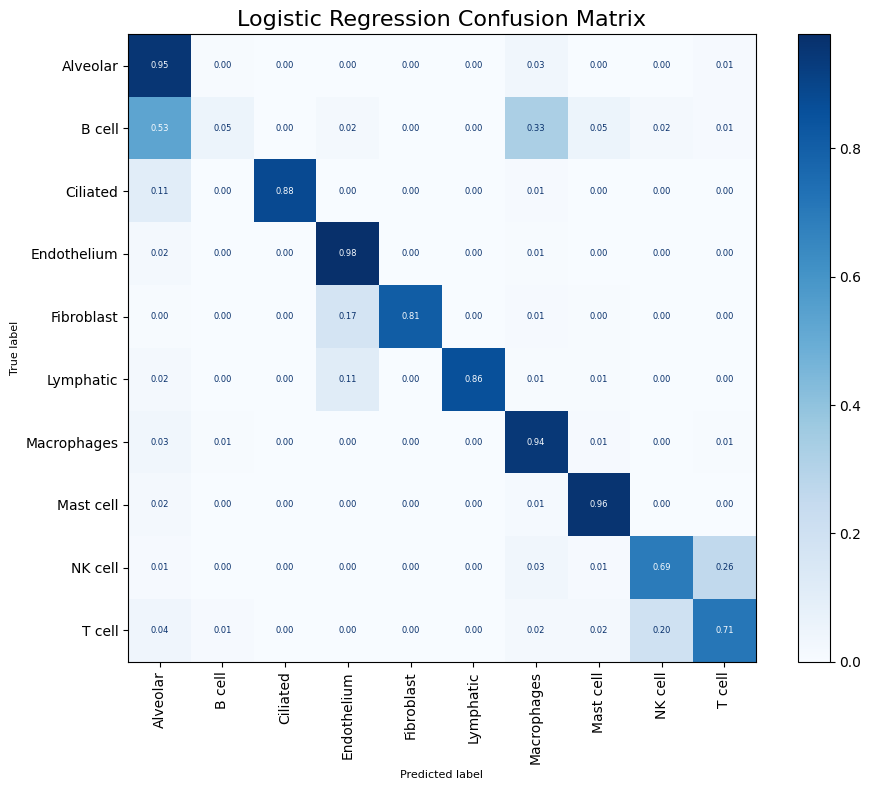


=== k-NN ===
Accuracy: 0.7982212340188994
              precision    recall  f1-score   support

    Alveolar       0.70      0.95      0.80      1834
      B cell       0.86      0.05      0.10      1250
    Ciliated       1.00      0.91      0.95       433
 Endothelium       0.91      0.96      0.93       360
  Fibroblast       0.98      0.91      0.94       204
   Lymphatic       1.00      0.94      0.97       195
 Macrophages       0.84      0.94      0.89      2878
   Mast cell       0.70      0.97      0.81       660
     NK cell       0.75      0.69      0.71       354
      T cell       0.81      0.83      0.82       827

    accuracy                           0.80      8995
   macro avg       0.85      0.81      0.79      8995
weighted avg       0.82      0.80      0.75      8995



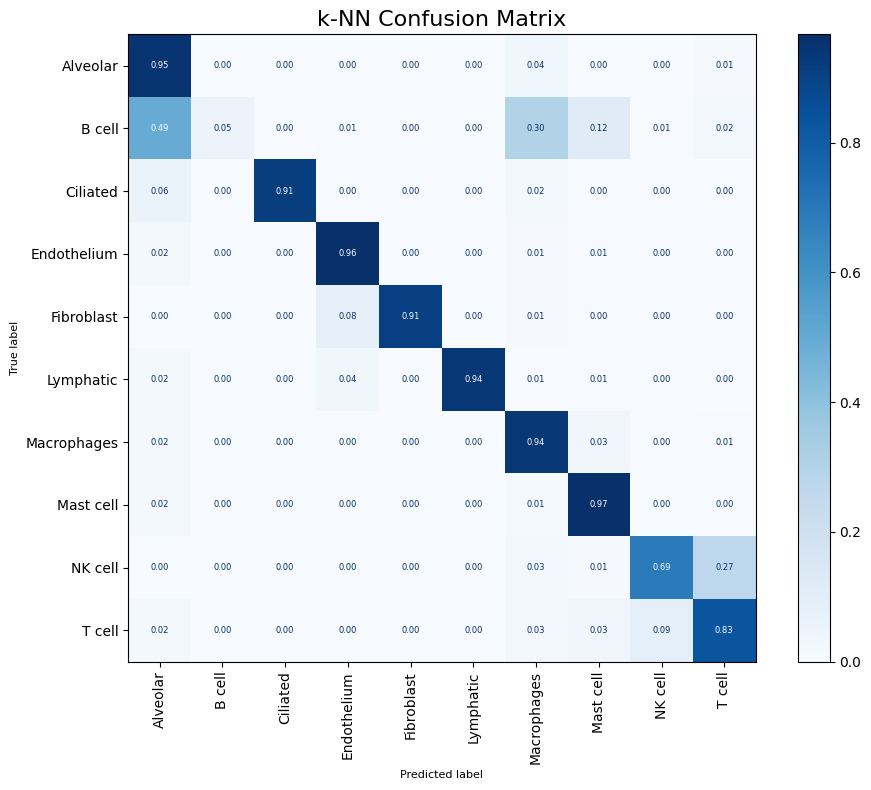

C:\Users\loq\AppData\Local\Temp\ipykernel_33800\777594820.py:156: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


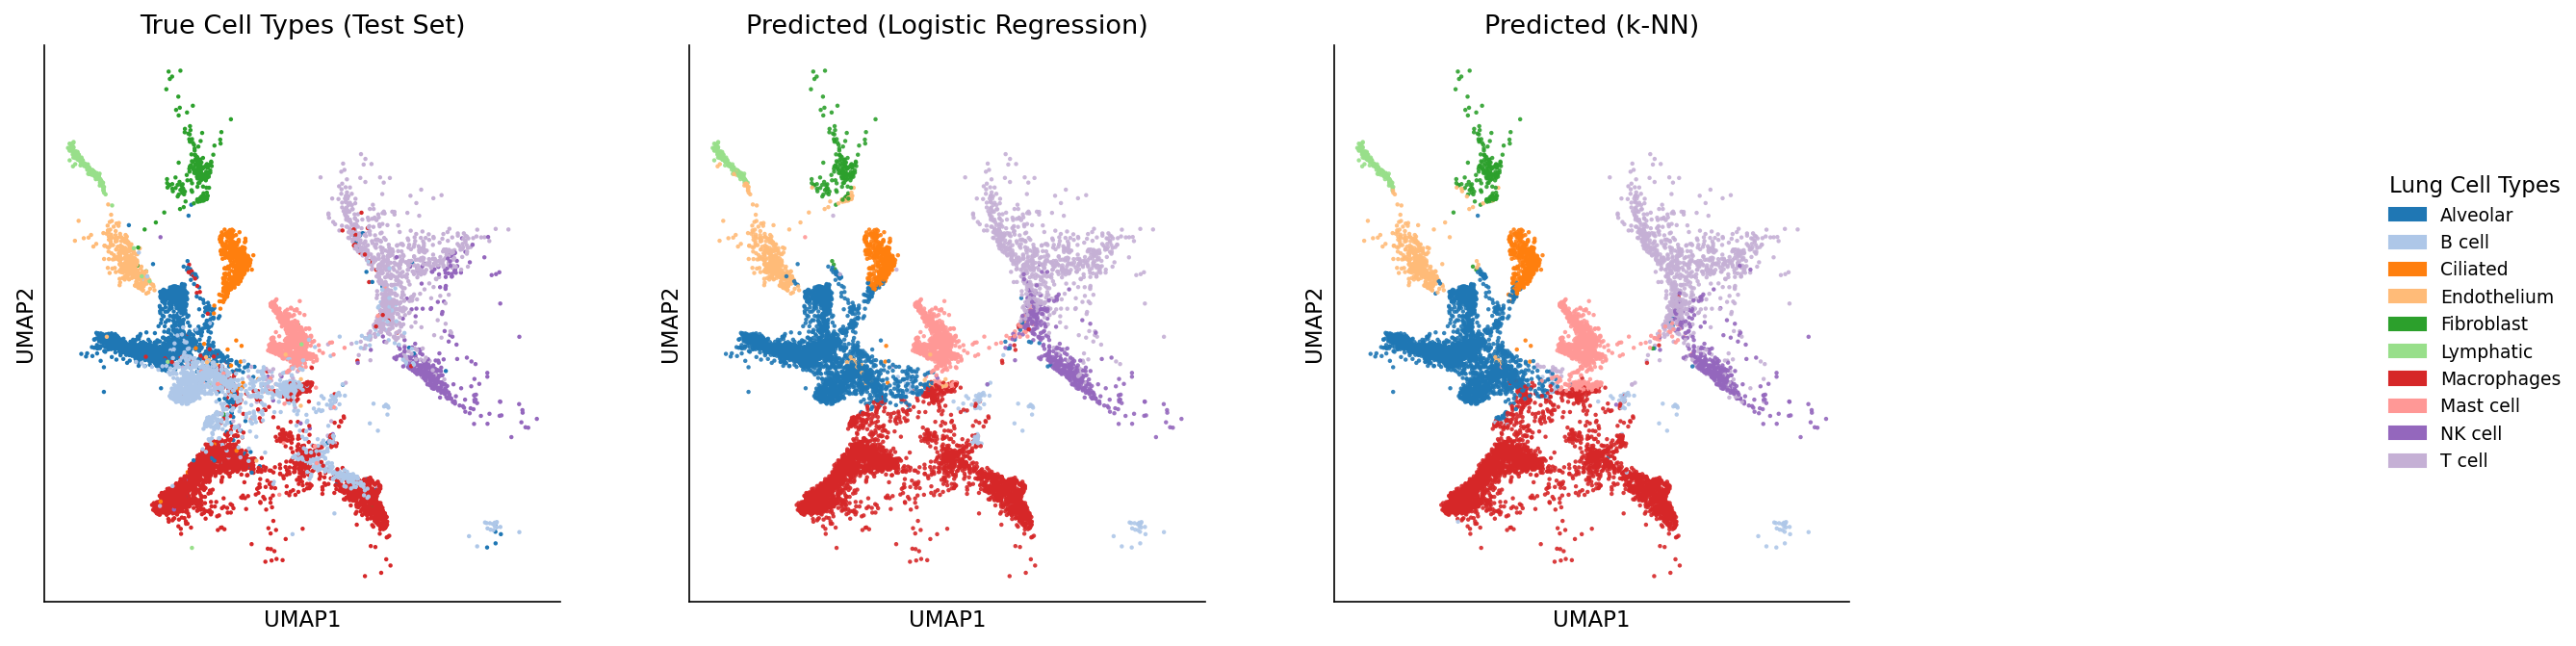

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
## Visualization

sc.pp.neighbors(adata_1, use_rep="X_emb")
sc.tl.umap(adata_1)

ax = sc.pl.umap(
    adata_1,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Lung: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='source',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Lung: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='dataset',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Lung: Dataset"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier 

train_data = adata_1[adata_1.obs["dataset"] == "Dataset1"]
test_data = adata_1[adata_1.obs["dataset"] == "Dataset2"]

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    # Reset to default style to ensure consistency
    plt.rcdefaults()
    plt.rcParams.update({
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'font.family': 'sans-serif',
        'font.size': 10,
    })

    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )
    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(6)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=8)
    plt.ylabel("True label", fontsize=8)

    plt.tight_layout()
    plt.show()
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Lung Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

In [7]:
label_keys = ["cell_type", "dataset"]


In [19]:
# NEW
scores_final_scimilarity = compute_silhouette_and_lisi_avg(adata_1, label_keys, embed_key="X_emb", k_lisi=30)
print("Silhouette Scores:", scores_final_scimilarity["silhouette"])
print("LISI Scores:", scores_final_scimilarity["lisi"])

Silhouette Scores: {'cell_type': 0.3793964982032776, 'dataset': 0.043191634118556976}
LISI Scores: {'cell_type': 1.0803541648072312, 'dataset': 1.0469571461987188}
